In [32]:
# Add the relevant scripts from LArMachineLearningData
# Nice the process so it can run with lots of cores on low priority
import os
os.nice(20)

# Add local paths
import sys
hnlDIR = os.environ['_']
sys.path.append('../pyscript')
sys.path.append('../bdtscript')

# From BDT Library
from importlib import reload
from PandoraBDT import *

# From pyscript Library
from Plotting import *
from Dictionary import *
from HelperFunctions import *
from CutFunctions import *

# Import relevant SKLearn stuff
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import validation_curve
from sklearn.model_selection import learning_curve
from sklearn import metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
#read in hdf5 to dataframe
hnl_path = "../hdf5_files/hnl_bdt_test_20k.h5"
nu_path = "../hdf5_files/nu_bdt_test_20k.h5"

dfslc_hnl, dfsubrun_hnl, dfmevprtl_hnl, dfmct_hnl = hdf5_to_dataframe(hnl_path)
dfslc_nu, dfsubrun_nu, _, dfmct_nu = hdf5_to_dataframe(nu_path)

#do scaling
scale_pot_hnl, hnl_spill = calc_scaling_pot(dfsubrun_hnl, dfslc_hnl)
scale_pot_nu, nu_spill = calc_scaling_pot(dfsubrun_nu, dfslc_nu)


-----------------------------------------------
sample pot = 1.3486129783746593e+22
sample spill = 19950
target spill = 1479.297642830312
scale pot factor = 0.07415025778598056
-----------------------------------------------
-----------------------------------------------
sample pot = 2.1481922917900754e+18
sample spill = 19850
target spill = 9240327.356104195
scale pot factor = 465.5076753704884
-----------------------------------------------


In [34]:
#temp fix:: eventtype 0 in nu sample is unknown
dfslc_nu['slc_true_event_type'][dfslc_nu['slc_true_event_type'] == 0] = -1


/tmp/ipykernel_20434/457812267.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfslc_nu['slc_true_event_type'][dfslc_nu['slc_true_event_type'] == 0] = -1


In [35]:
true_counts, true_nonfv_counts = get_true_signal_in_all_spills(dfmct_hnl , scale_pot_hnl)
istart_counts, start_nonfv_counts = get_reco_signal_in_all_spills(dfslc_hnl, scale_pot_hnl)


In [4]:
#Remove clear cosmics
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_is_clear_cosmics'] == False]
dfslc_nu = dfslc_nu[dfslc_nu['slc_is_clear_cosmics'] == False]

In [5]:
#Valid Opt0
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_opt0_score'] >0]
dfslc_nu = dfslc_nu[dfslc_nu['slc_opt0_score'] >0]

In [6]:
#Only Keep Higher Energy Shower PFP per slice
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_pfp_shower_energy'] == dfslc_hnl.groupby(['run','subrun','event','slc_idx'])["slc_pfp_shower_energy"].transform(max)]
dfslc_nu = dfslc_nu[dfslc_nu['slc_pfp_shower_energy'] == dfslc_nu.groupby(['run','subrun','event','slc_idx'])["slc_pfp_shower_energy"].transform(max)]

In [7]:
#Valid Shower Object: Length
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_pfp_shower_length'] > 0]
dfslc_nu = dfslc_nu[dfslc_nu['slc_pfp_shower_length'] > 0]

In [8]:
#Valid Shower Object: Energy
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_pfp_shower_energy'] > 0]
dfslc_nu = dfslc_nu[dfslc_nu['slc_pfp_shower_energy'] > 0]

In [9]:
#Valid Shower Object: Direction
dfslc_hnl = dfslc_hnl[(dfslc_hnl['slc_pfp_shower_angle_to_beam'] >= 0) & (dfslc_hnl['slc_pfp_shower_angle_to_beam'] <= 180)]
dfslc_nu = dfslc_nu[(dfslc_nu['slc_pfp_shower_angle_to_beam'] >= 0) & (dfslc_nu['slc_pfp_shower_angle_to_beam'] <= 180)]

In [10]:
#Valid Track Object: Length
dfslc_hnl = dfslc_hnl[dfslc_hnl['slc_pfp_track_length'] > 0]
dfslc_nu = dfslc_nu[dfslc_nu['slc_pfp_track_length'] > 0]

In [11]:
#Valid Track Object: Energy
dfslc_hnl = dfslc_hnl[(dfslc_hnl['slc_pfp_track_ke'] > 0) & (dfslc_hnl['slc_pfp_track_ke'] < 1e9)]
dfslc_nu = dfslc_nu[(dfslc_nu['slc_pfp_track_ke'] > 0) & (dfslc_nu['slc_pfp_track_ke'] < 1e9)]

In [12]:
#Valid Track Object: Direction
dfslc_hnl = dfslc_hnl[(dfslc_hnl['slc_pfp_track_angle_to_beam'] >= 0) & (dfslc_hnl['slc_pfp_track_angle_to_beam'] <= 180)]
dfslc_nu = dfslc_nu[(dfslc_nu['slc_pfp_track_angle_to_beam'] >= 0) & (dfslc_nu['slc_pfp_track_angle_to_beam'] <= 180)]

In [13]:
dfslc_hnl

,run,subrun,event,slc_is_clear_cosmics,slc_vtx_x,slc_vtx_y,slc_vtx_z,slc_crumbs_score,slc_opt0_score,slc_opt0_frac,...,slc_pfp_track_angle_to_beam,slc_pfp_track_contained,slc_pfp_shower_conv_gap,slc_pfp_shower_length,slc_pfp_shower_open_angle,slc_pfp_shower_energy,slc_pfp_shower_dedx,slc_pfp_shower_angle_to_beam,slc_pfp_shower_contained,scale_pot
0,1,1,1,False,144.991104,182.931259,350.705231,0.573993,14882.375401,-0.002815,...,8.565947,False,1.00824,105.21123,0.178085,1126.970434,2.200317,4.202856,True,0.07415
13,1,1,2,False,-53.712463,-34.675556,116.567421,0.717914,21040.361210,0.153798,...,33.342117,True,14.885709,94.185735,0.177751,1515.454563,1.531393,5.743063,True,0.07415
25,1,1,3,False,49.821865,200.766510,22.178991,-0.515852,5.901875,-0.679611,...,90.691452,False,0.230259,55.898958,0.05024,172.944012,2.543257,90.304581,False,0.07415
26,1,1,3,False,117.118645,-150.202621,413.939178,0.661890,14877.687157,0.051746,...,5.92487,False,1.953319,68.927472,0.23634,495.457528,8.296883,6.434534,True,0.07415
38,1,1,4,False,181.738037,19.320147,309.604279,0.628089,11523.074690,-0.106815,...,1.328557,True,0.40985,115.265776,0.186607,1639.200419,6.104753,2.140803,True,0.07415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294961,1,1096,45,False,-60.323456,52.428181,224.177643,0.110277,2235.505359,-0.133859,...,159.930359,True,0.609577,6.930097,0.105514,42.960723,3.05063,161.073364,True,0.07415
294976,1,1096,46,False,-113.190300,17.177237,96.462875,0.463635,1785.429853,-0.119624,...,6.238781,True,55.467575,61.841194,0.124275,183.74211,1.245996,9.650056,True,0.07415
294986,1,1096,47,False,-142.628418,-30.332121,486.225372,0.330217,3448.869521,-0.598770,...,8.059492,False,2.415473,17.197863,0.374817,130.924272,6.446225,38.800678,False,0.07415
295001,1,1096,48,False,-128.431900,157.136810,140.293640,0.159469,674.844163,-0.050927,...,18.450157,False,64.604731,16.539419,0.154269,131.063923,4.736358,17.058887,False,0.07415


In [16]:
trainBDT = LoadFromPkl('../BDT_notebook/TestBDT.pkl')
print(trainBDT)

AdaBoostClassifier(algorithm='SAMME',
                   base_estimator=DecisionTreeClassifier(max_depth=2),
                   n_estimators=55, random_state=42)


In [17]:
featureNames =['slc_vtx_x',
 'slc_vtx_y',
 'slc_vtx_z',
 'slc_crumbs_score',
 'slc_opt0_score',
 'slc_opt0_frac',
 'slc_opt0_time_corrected_Z_pandora',
 'slc_n_stub',
 'slc_n_razzled_electrons',
 'slc_n_razzled_muons',
 'slc_n_razzled_photons',
 'slc_n_razzled_pions_thresh',
 'slc_n_razzled_protons_thresh',
 'slc_n_primary_razzled_electrons',
 'slc_n_primary_razzled_muons',
 'slc_n_primary_razzled_photons',
 'slc_n_primary_razzled_pions_thresh',
 'slc_n_primary_razzled_protons_thresh',
 'slc_pfp_n_hits',
 'slc_pfp_track_score',
 'slc_pfp_razzled_electron_score',
 'slc_pfp_razzled_muon_score',
 'slc_pfp_razzled_photon_score',
 'slc_pfp_razzled_pion_score',
 'slc_pfp_razzled_proton_score',
 'slc_pfp_track_length',
 'slc_pfp_track_ke',
 'slc_pfp_track_angle_to_beam',
 'slc_pfp_track_contained',
 'slc_pfp_shower_conv_gap',
 'slc_pfp_shower_length',
 'slc_pfp_shower_open_angle',
 'slc_pfp_shower_energy',
 'slc_pfp_shower_dedx',
 'slc_pfp_shower_angle_to_beam',
 'slc_pfp_shower_contained']

In [20]:
dfslc_hnl['bdtInput'] = dfslc_hnl[featureNames].values.tolist()

dfslc_hnl['bdtInput'] = dfslc_hnl['bdtInput'].apply(lambda x: np.array(x))
dfslc_hnl['bdtInput'] = dfslc_hnl['bdtInput'].apply(lambda x: x.reshape(1,-1))

In [21]:
import time
start_time = time.time()

In [24]:
dfslc_hnl['bdtScore'] = dfslc_hnl['bdtInput'].apply(lambda x: trainBDT.decision_function(x))
print("--- %s seconds ---" % (time.time() - start_time))

--- 150.80537486076355 seconds ---


In [26]:
dfslc_hnl = dfslc_hnl.drop(['bdtInput'], axis=1)

In [28]:
dfslc_hnl['bdtScore'] = dfslc_hnl['bdtScore'].apply(lambda x: x[0])

(-1.0, 1.0)

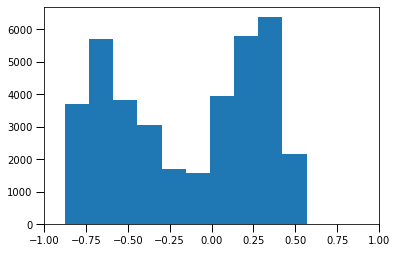

In [31]:
plt.hist(dfslc_hnl['bdtScore'])
plt.xlim(-1, 1)